In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('IPL Matches 2008-2020.csv')

In [3]:
df.head()

,id,city,date,player_of_match,venue,neutral_venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,eliminator,method,umpire1,umpire2
0,335982,Bangalore,2008-04-18,BB McCullum,M Chinnaswamy Stadium,0,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,Chandigarh,2008-04-19,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",0,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,N,NaN,MR Benson,SL Shastri
2,335984,Delhi,2008-04-19,MF Maharoof,Feroz Shah Kotla,0,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,Mumbai,2008-04-20,MV Boucher,Wankhede Stadium,0,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,N,NaN,SJ Davis,DJ Harper
4,335986,Kolkata,2008-04-20,DJ Hussey,Eden Gardens,0,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,N,NaN,BF Bowden,K Hariharan


In [7]:
df.isnull().mean()*100

id                  0.000000
city                1.593137
date                0.000000
player_of_match     0.490196
venue               0.000000
neutral_venue       0.000000
team1               0.000000
team2               0.000000
toss_winner         0.000000
toss_decision       0.000000
winner              0.490196
result              0.490196
result_margin       2.083333
eliminator          0.490196
method             97.671569
umpire1             0.000000
umpire2             0.000000
dtype: float64

In [10]:
cols = [var for var in df.columns if df[var].isnull().mean()*100 < 5 and df[var].isnull().mean()*100 > 0]
cols

['city', 'player_of_match', 'winner', 'result', 'result_margin', 'eliminator']

In [12]:
df[cols].sample(3)

,city,player_of_match,winner,result,result_margin,eliminator
683,Indore,UT Yadav,Royal Challengers Bangalore,wickets,10.0,N
329,Jaipur,SK Trivedi,Rajasthan Royals,runs,19.0,N
446,Kolkata,RV Uthappa,Kolkata Knight Riders,runs,30.0,N


In [18]:
df['eliminator'].nunique()

2

In [14]:
len(df[cols].dropna()) / len(df)

0.9632352941176471

In [15]:
new_df = df[cols].dropna()
df.shape, new_df.shape

((816, 17), (786, 6))

<Axes: >

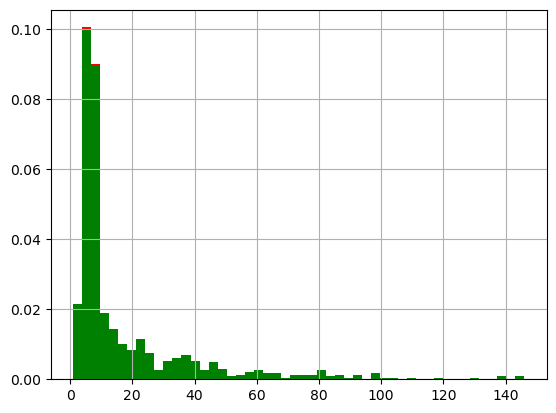

In [19]:
fig = plt.figure()
ax = plt.subplot(111)

#original Data
df['result_margin'].hist(bins=50, ax=ax, color='red', density='True')

# data after cca, the argument alpha makes the color transparent, so we can
# see the overlay of the 2 distributions
new_df['result_margin'].hist(bins=50, ax=ax, color='green', density='True')

<Axes: ylabel='Density'>

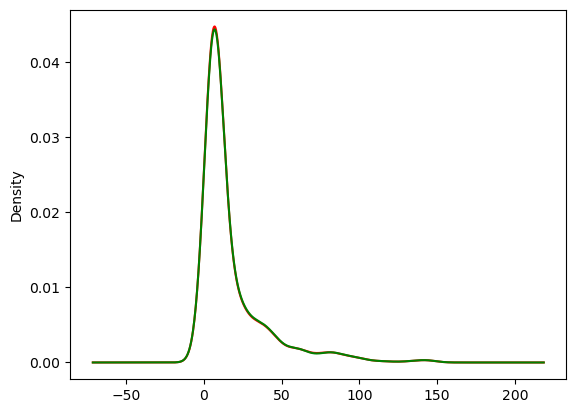

In [20]:
fig = plt.figure()
ax = plt.subplot(111)

#original Data
df['result_margin'].plot.density(color='red')

# data after cca
new_df['result_margin'].plot.density(color='green')

In [21]:
temp = pd.concat([
    df['city'].value_counts() / len(df),
    new_df['city'].value_counts() / len(new_df)
],axis=1)

temp.columns= ['original','CCA']

temp

,original,CCA
city,,
Mumbai,0.123775,0.127226
Kolkata,0.094363,0.097964
Delhi,0.090686,0.091603
Bangalore,0.079657,0.078880
Hyderabad,0.078431,0.080153
Chennai,0.069853,0.071247
Chandigarh,0.068627,0.071247
Jaipur,0.057598,0.059796
Pune,0.046569,0.048346


In [22]:
temp = pd.concat([
    df['player_of_match'].value_counts() / len(df),
    new_df['player_of_match'].value_counts() / len(new_df)
],axis=1)

temp.columns= ['original','CCA']

temp

,original,CCA
player_of_match,,
AB de Villiers,0.028186,0.027990
CH Gayle,0.026961,0.027990
RG Sharma,0.022059,0.022901
DA Warner,0.020833,0.021628
MS Dhoni,0.020833,0.021628
...,...,...
S Anirudha,0.001225,0.001272
M Kartik,0.001225,0.001272
R McLaren,0.001225,0.001272


In [23]:
temp = pd.concat([
    df['winner'].value_counts() / len(df),
    new_df['winner'].value_counts() / len(new_df)
],axis=1)

temp.columns= ['original','CCA']

temp

,original,CCA
winner,,
Mumbai Indians,0.147059,0.150127
Chennai Super Kings,0.129902,0.131043
Kolkata Knight Riders,0.121324,0.123410
Royal Challengers Bangalore,0.111520,0.110687
Kings XI Punjab,0.107843,0.104326
Rajasthan Royals,0.099265,0.100509
Delhi Daredevils,0.082108,0.082697
Sunrisers Hyderabad,0.080882,0.080153
Deccan Chargers,0.035539,0.036896


In [24]:
temp = pd.concat([
    df['result'].value_counts() / len(df),
    new_df['result'].value_counts() / len(new_df)
],axis=1)

temp.columns= ['original','CCA']

temp

,original,CCA
result,,
wickets,0.533088,0.543257
runs,0.446078,0.456743
tie,0.015931,NaN


In [25]:
temp = pd.concat([
    df['eliminator'].value_counts() / len(df),
    new_df['eliminator'].value_counts() / len(new_df)
],axis=1)

temp.columns= ['original','CCA']

temp

,original,CCA
eliminator,,
N,0.979167,1.0
Y,0.015931,NaN
